# Dataset Analysis

## Feature Reference Guide (FUNA-DB)
Based on Räsänen et al. (2021) and Hakkarainen et al. (2025).

| Column | Full Name | Factor | Score Type | Direction |
|--------|-----------|--------|------------|-----------|
| NC | Number Comparison | Number Processing | Efficiency index (RT ÷ accuracy) | **Higher = worse** (slower/less accurate) |
| DM | Digit-Dot Matching | Number Processing | Efficiency index (RT ÷ accuracy) | **Higher = worse** (slower/less accurate) |
| NS | Number Series | Arithmetic Fluency | # correct items (3 min) | Higher = better |
| ADD | Single-Digit Addition | Arithmetic Fluency | # correct items (2 min) | Higher = better |
| SUB | Single-Digit Subtraction | Arithmetic Fluency | # correct items (2 min) | Higher = better |
| CA | Multi-Digit Calculations | Arithmetic Fluency | # correct items (3 min) | Higher = better |

**Important notes for interpretation:**
- NC and DM are efficiency scores — a student with dyscalculia will score *higher* on these (slow + inaccurate)
- NS, ADD, SUB, CA are speed-accuracy counts — a student with dyscalculia will score *lower* on these
- This means NC/DM correlate *negatively* with ADD/SUB/CA — this is **expected and correct**, not a data error
- NC and DM are **not inverted** here because C4.5 Decision Tree is direction-agnostic — it will learn the correct split thresholds regardless
- The two-factor structure (Number Processing vs Arithmetic Fluency) is validated across 18,405 students (Hellstrand et al., 2024)

## Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

AT_RIST_COLOR = '#ED7D31'
TYPICAL_COLOR = '#5B9BD5'

## 1. Exploratory Data Analysis — Before Cleaning

### 1.1 Initial View of the Dataset

In [2]:
df_raw = pd.read_csv("dataset/FUNADB_labled.csv")

print("=== Dataset Info ===")
print(df_raw.info())

print("\n=== Dataset Head ===")
print(df_raw.head())

print("\n=== Summary Statistics (raw) ===")
print(df_raw.describe().T.round(2))

print("\n=== Missing / Sentinel Values ===")
default_missing_val = -99
sentinel_mask = (df_raw == default_missing_val)
print(f"Cells equal to {default_missing_val}:", sentinel_mask.sum().sum())
print(sentinel_mask.sum()[sentinel_mask.sum() > 0])

print("\n=== Label Distribution ===")
print(df_raw['Label'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NC      358 non-null    float64
 1   DM      358 non-null    float64
 2   NS      358 non-null    int64  
 3   ADD     358 non-null    int64  
 4   SUB     358 non-null    int64  
 5   CA      358 non-null    int64  
 6   Label   358 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 19.7 KB
None

=== Dataset Head ===
            NC           DM  NS  ADD  SUB  CA  Label
0  1248.000000  2903.384615   5   23   17   8      1
1   921.142857  2212.000000  21   48   22  29      0
2   902.720000  1943.846154  14   28   26  18      1
3  1334.297872  3707.268293   9   17   10 -99      1
4  1274.509804  2384.918919  16   34   37  16      0

=== Summary Statistics (raw) ===
       count     mean     std   min      25%      50%      75%      max
NC     358.0   993.86  329.90 -99.0   75

### 1.2 Label Distribution

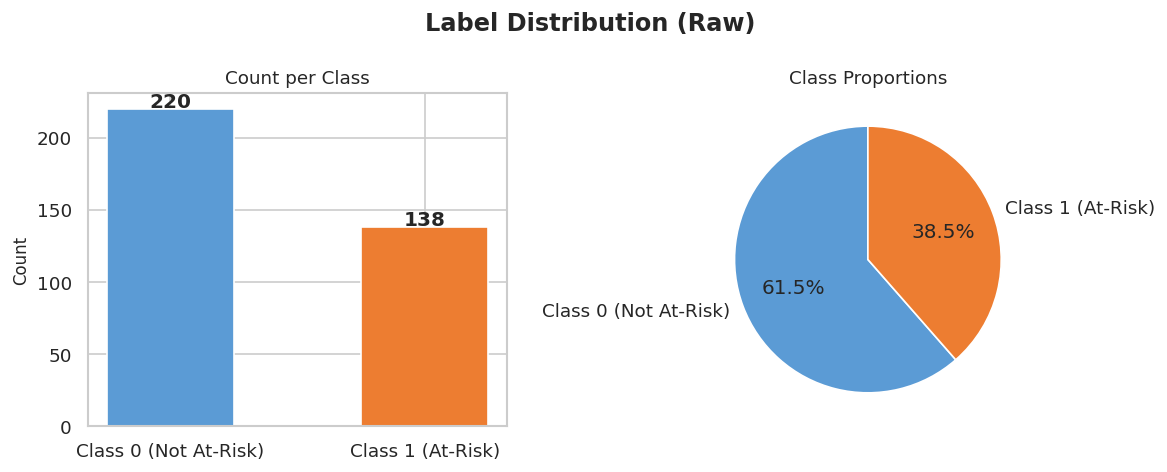

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Label Distribution (Raw)', fontweight='bold')

counts = df_raw['Label'].value_counts().sort_index()
labels = ['Class 0 (Not At-Risk)', 'Class 1 (At-Risk)']
colors = [TYPICAL_COLOR, AT_RIST_COLOR]

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylabel('Count')
axes[0].set_title('Count per Class')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

### 1.3 Feature Distribution

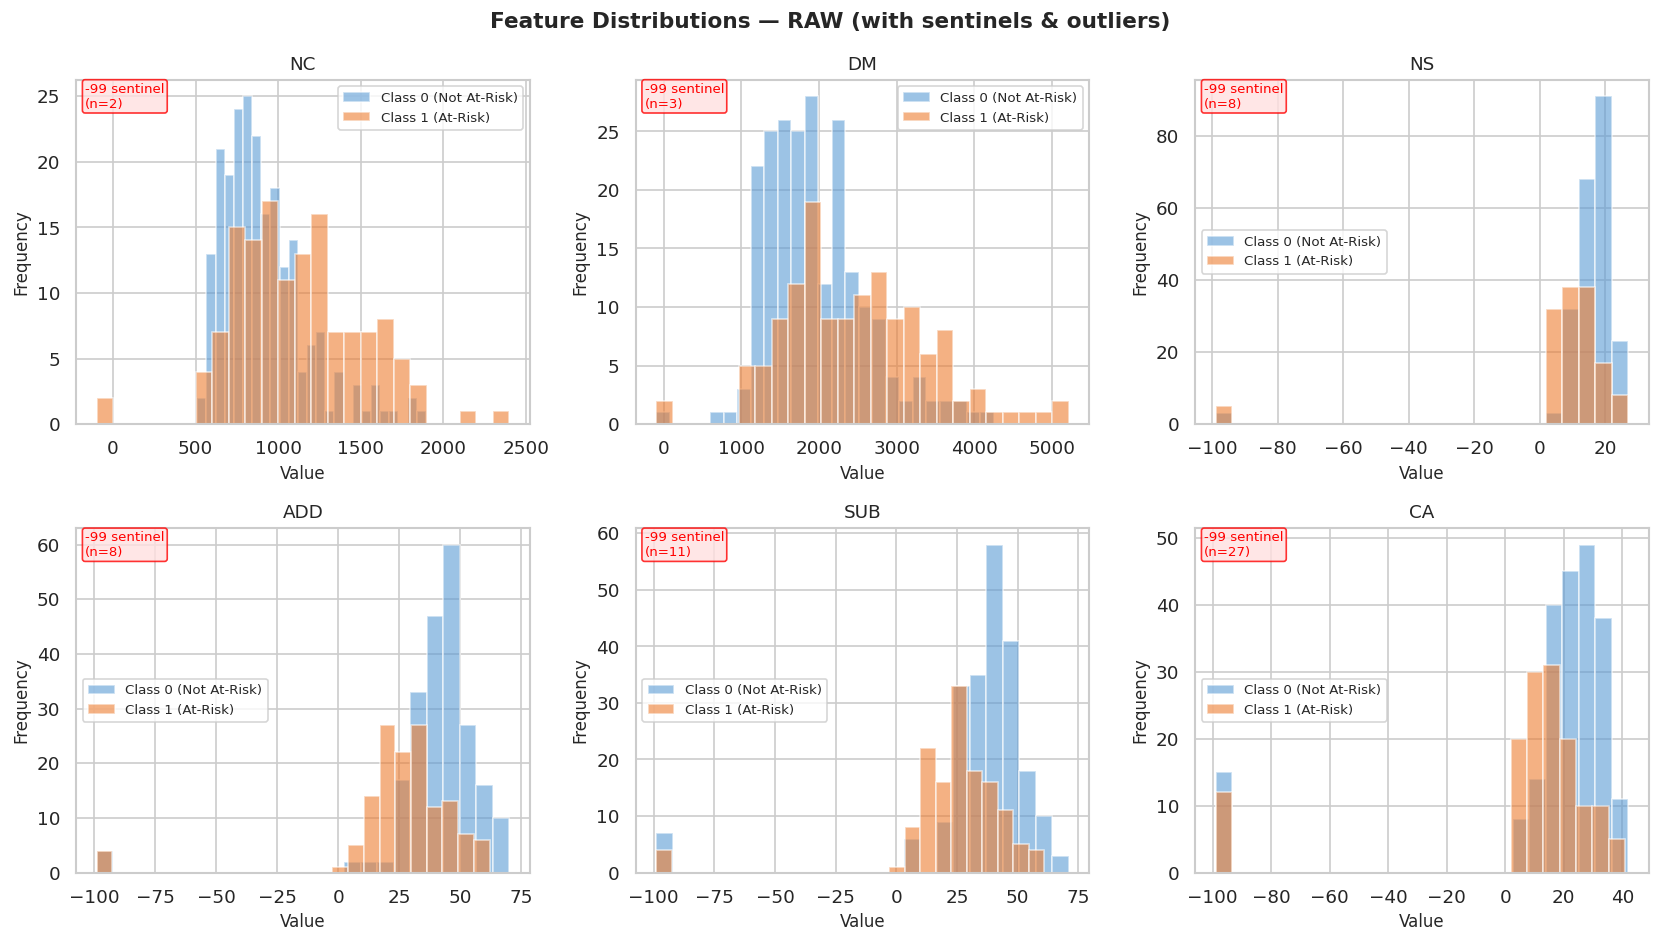

In [ ]:
feature_cols = [c for c in df_raw.columns if c != 'Label']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions — RAW (with sentinels & outliers)', fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    for label, color in zip([0, 1], [TYPICAL_COLOR, AT_RIST_COLOR]):
        data = df_raw[df_raw['Label'] == label][col]
        ax.hist(data, bins=25, alpha=0.6, color=color,
                label=f'Class {label} ({["Not At-Risk","At-Risk"][label]})', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    # Annotate sentinel values
    n_sentinel = (df_raw[col] == default_missing_val).sum()
    if n_sentinel > 0:
        ax.annotate(f'{default_missing_val} sentinel\n(n={n_sentinel})', xy=(0.02, 0.92),
                    xycoords='axes fraction', fontsize=8, color='red',
                    bbox=dict(boxstyle='round,pad=0.2', fc='#ffe0e0', ec='red', alpha=0.8))

plt.tight_layout()
plt.show()

### 1.4 Feature x Class Outliers

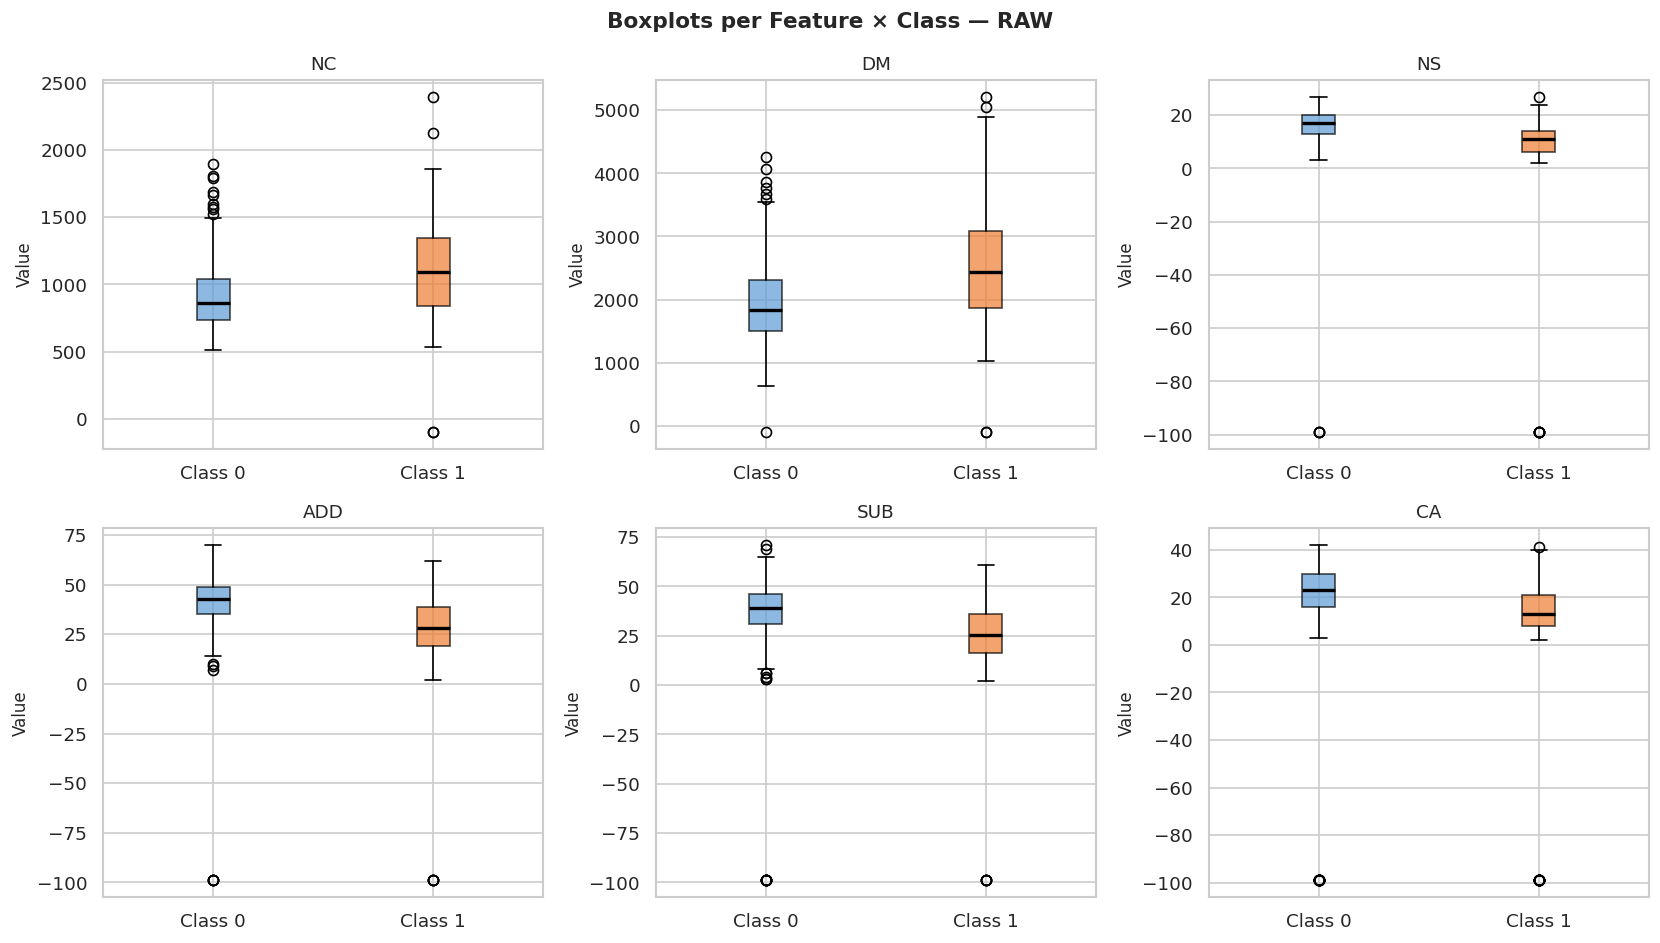

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Boxplots per Feature × Class — RAW', fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    data_to_plot = [df_raw[df_raw['Label'] == lbl][col].dropna() for lbl in [0, 1]]
    bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], [TYPICAL_COLOR, AT_RIST_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Class 0', 'Class 1'])
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

### 1.5 Correlation Matrix

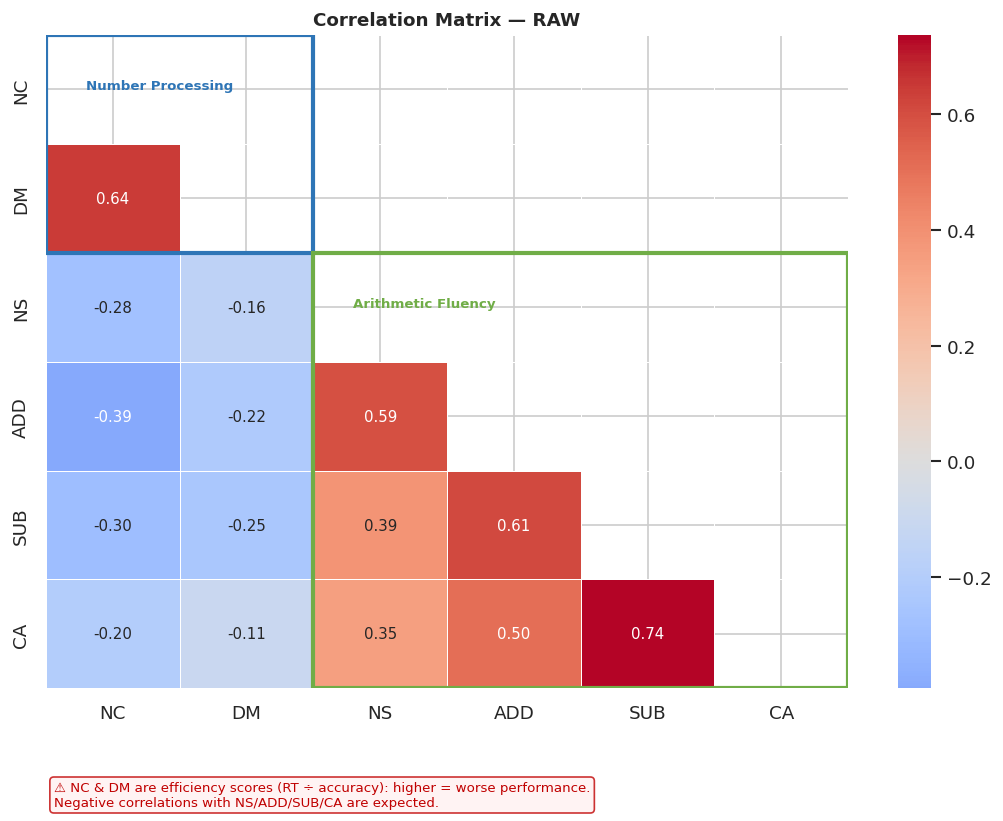

In [6]:
# Two-factor grouping
number_processing = ['NC', 'DM']
arithmetic_fluency = ['NS', 'ADD', 'SUB', 'CA']

# Correlation (exclude Label unless you really need it)
corr_raw = df_raw[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_raw, dtype=bool))

sns.heatmap(corr_raw, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})

ax.set_title('Correlation Matrix — RAW', fontweight='bold')

# --- Dynamic mapping (fixes your main issue) ---
col_index = {col: i for i, col in enumerate(corr_raw.columns)}

# Number Processing
np_idx = [col_index[c] for c in number_processing if c in col_index]
if np_idx:
    np_min, np_max = min(np_idx), max(np_idx)
    ax.add_patch(plt.Rectangle(
        (np_min, np_min),
        np_max - np_min + 1,
        np_max - np_min + 1,
        fill=False,
        edgecolor='#2E75B6',
        lw=2.5
    ))
    ax.text(np_min + 0.3, np_min + 0.5, 'Number Processing',
            fontsize=8, color='#2E75B6', fontweight='bold')

# Arithmetic Fluency
af_idx = [col_index[c] for c in arithmetic_fluency if c in col_index]
if af_idx:
    af_min, af_max = min(af_idx), max(af_idx)
    ax.add_patch(plt.Rectangle(
        (af_min, af_min),
        af_max - af_min + 1,
        af_max - af_min + 1,
        fill=False,
        edgecolor='#70AD47',
        lw=2.5
    ))
    ax.text(af_min + 0.3, af_min + 0.5, 'Arithmetic Fluency',
            fontsize=8, color='#70AD47', fontweight='bold')

# --- Stable annotation (fix clipping issue) ---
ax.text(
    0.01, -0.18,
    '⚠ NC & DM are efficiency scores (RT ÷ accuracy): higher = worse performance.\n'
    'Negative correlations with NS/ADD/SUB/CA are expected.',
    transform=ax.transAxes,
    fontsize=8,
    color='#C00000',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='#C00000', alpha=0.8)
)

plt.tight_layout()
plt.show()

### 1.6 Pairplot

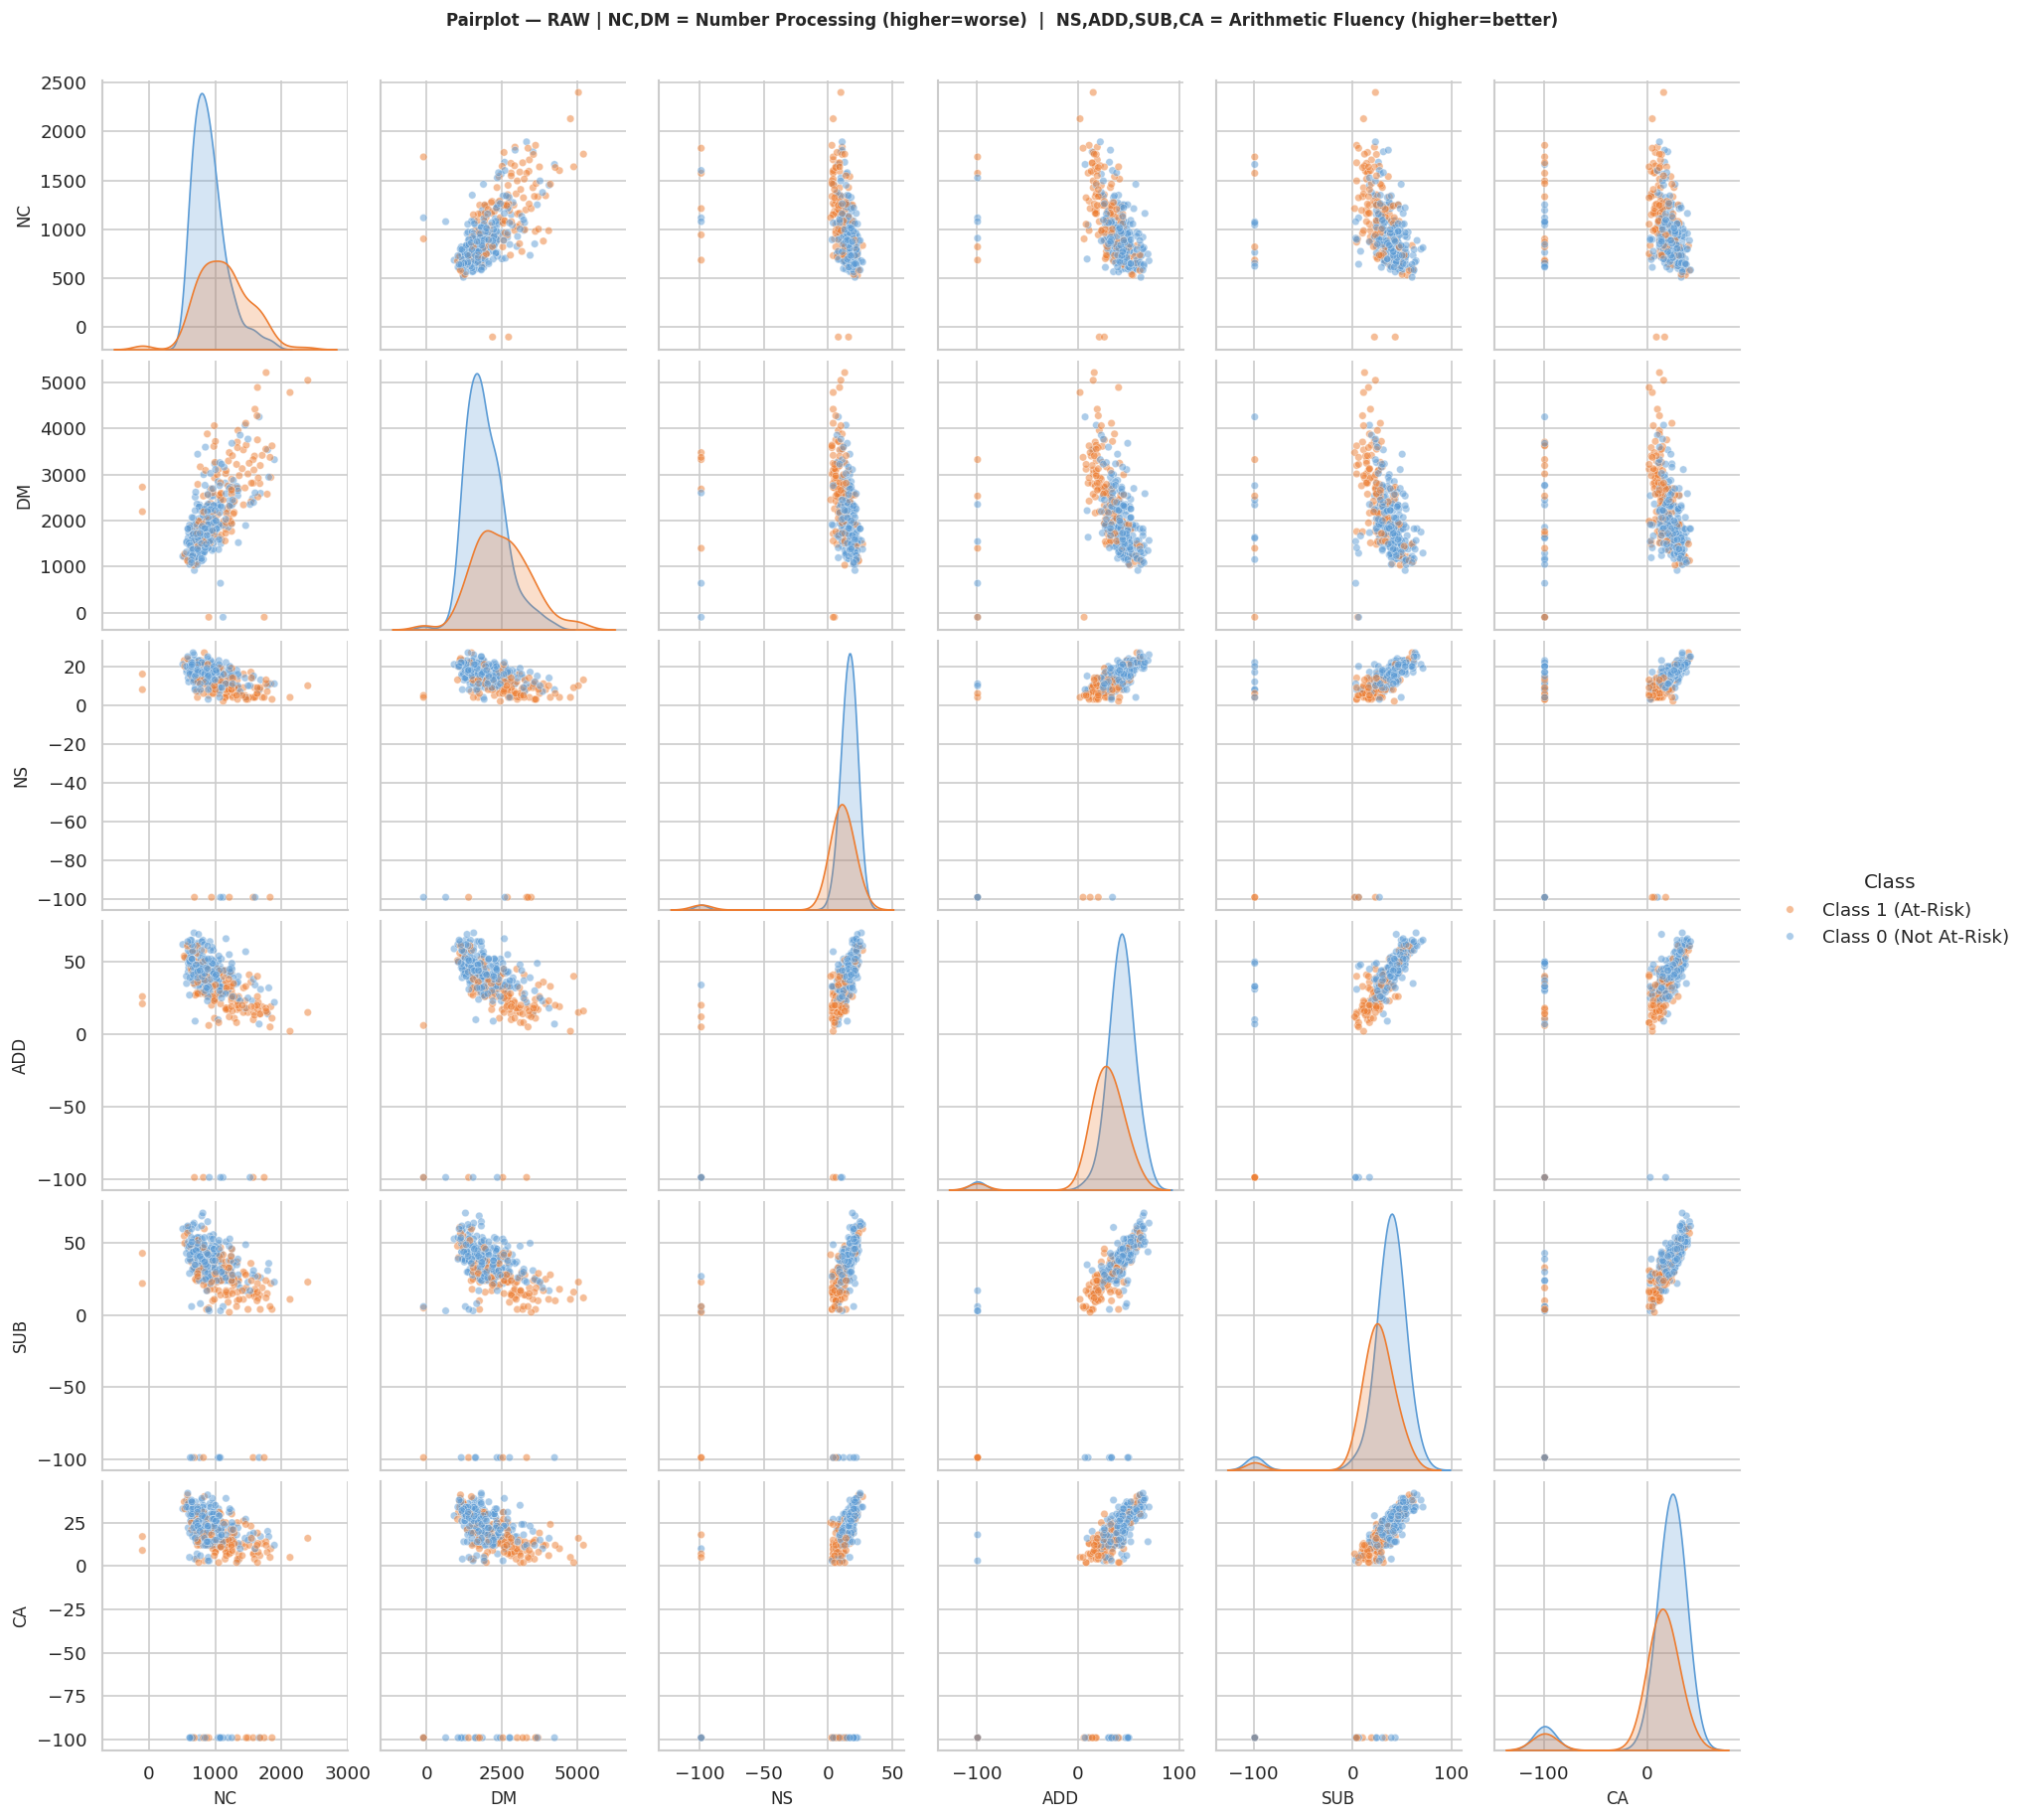

In [7]:
pair_df = df_raw.copy()
pair_df['Class'] = pair_df['Label'].map({0: 'Class 0 (Not At-Risk)', 1: 'Class 1 (At-Risk)'})

# Highlight the two-factor structure with column ordering
# Number Processing: NC, DM | Arithmetic Fluency: NS, ADD, SUB, CA
ordered_cols = ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA']
g = sns.pairplot(pair_df, vars=ordered_cols, hue='Class',
                 palette={'Class 0 (Not At-Risk)': TYPICAL_COLOR, 'Class 1 (At-Risk)': AT_RIST_COLOR},
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
g.figure.suptitle(
    'Pairplot — RAW | NC,DM = Number Processing (higher=worse)  |  NS,ADD,SUB,CA = Arithmetic Fluency (higher=better)',
    y=1.02, fontweight='bold', fontsize=10)
plt.show()

## 2. Cleanup Dataset

### 2.1 Replace known invalid sentinels

In [8]:
df = df_raw.copy()
df = df.replace([-99], np.nan)

### 2.2 Ensure numeric safety (no negatives allowed in this dataset)

In [9]:
for col in df.columns:
    if col == 'Label':
        continue
    df.loc[df[col] < 0, col] = np.nan

print('NaN counts after sentinel/negative removal:')
print(df[feature_cols].isna().sum())

NaN counts after sentinel/negative removal:
NC      2
DM      3
NS      8
ADD     8
SUB    11
CA     27
dtype: int64


#### 2.2.1 Analyse Missingness by Class
Since missing values represent absent/incomplete students (not random), we first check whether missingness is disproportionate in the At-Risk class. If so, it is itself a diagnostic signal and must be preserved as indicator flags before imputing.

In [10]:
print("=== Missing counts per feature per class ===")
missing_by_class = df.groupby('Label')[feature_cols].apply(lambda x: x.isna().sum())
missing_by_class.index = ['Not At-Risk (0)', 'At-Risk (1)']
print(missing_by_class)

print("\n=== Missing rate (%) per feature per class ===")
missing_rate = df.groupby('Label')[feature_cols].apply(
    lambda x: (x.isna().sum() / len(x) * 100).round(1)
)
missing_rate.index = ['Not At-Risk (0)', 'At-Risk (1)']
print(missing_rate)

=== Missing counts per feature per class ===
                 NC  DM  NS  ADD  SUB  CA
Not At-Risk (0)   0   1   3    4    7  15
At-Risk (1)       2   2   5    4    4  12

=== Missing rate (%) per feature per class ===
                  NC   DM   NS  ADD  SUB   CA
Not At-Risk (0)  0.0  0.5  1.4  1.8  3.2  6.8
At-Risk (1)      1.4  1.4  3.6  2.9  2.9  8.7


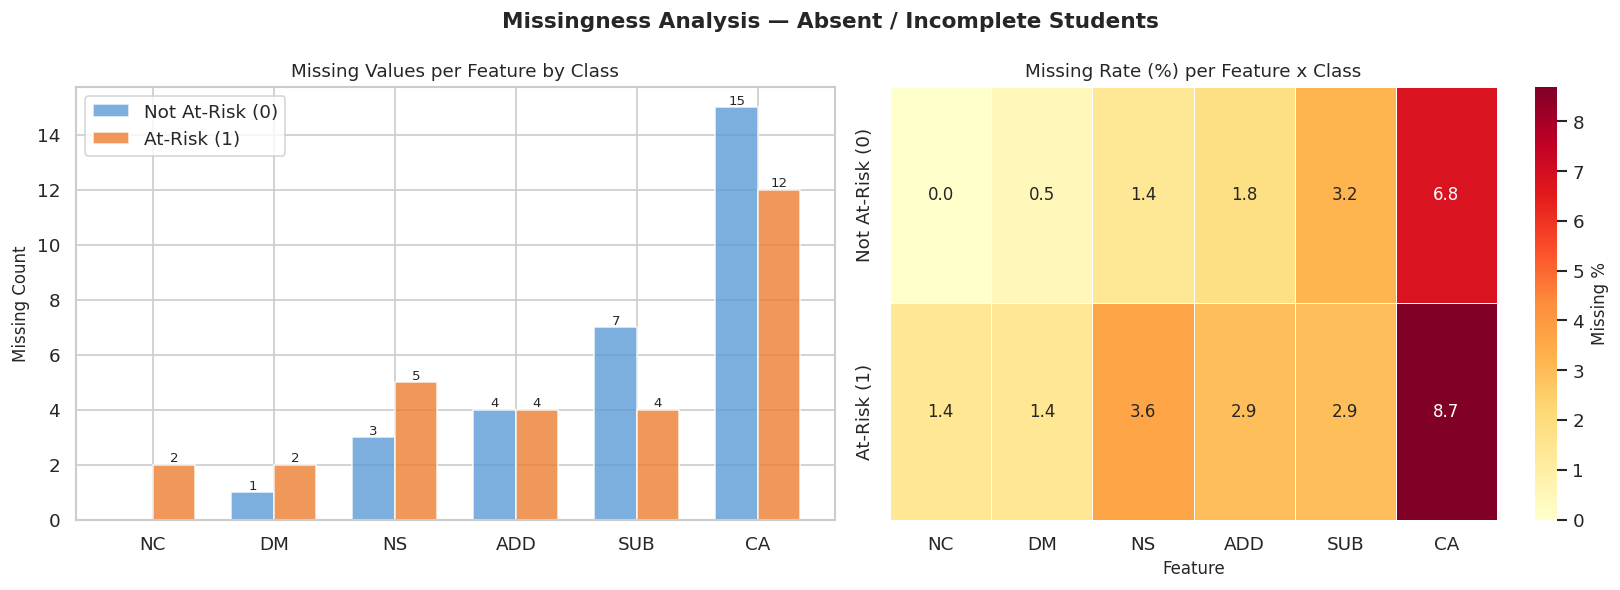


59 missing values found. Proceeding to create indicator flags.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missingness Analysis — Absent / Incomplete Students', fontweight='bold', fontsize=13)

# Chart 1: Missing count per feature, grouped by class
ax = axes[0]
miss_c0 = df[df['Label'] == 0][feature_cols].isna().sum()
miss_c1 = df[df['Label'] == 1][feature_cols].isna().sum()
x = np.arange(len(feature_cols))
width = 0.35
ax.bar(x - width/2, miss_c0, width, label='Not At-Risk (0)', color=TYPICAL_COLOR, alpha=0.8)
ax.bar(x + width/2, miss_c1, width, label='At-Risk (1)',     color=AT_RIST_COLOR, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(feature_cols)
ax.set_ylabel('Missing Count')
ax.set_title('Missing Values per Feature by Class')
ax.legend()
for xi, (v0, v1) in enumerate(zip(miss_c0, miss_c1)):
    if v0 > 0: ax.text(xi - width/2, v0 + 0.1, str(v0), ha='center', fontsize=8)
    if v1 > 0: ax.text(xi + width/2, v1 + 0.1, str(v1), ha='center', fontsize=8)

# Chart 2: Missing rate heatmap
ax2 = axes[1]
rate_data = pd.DataFrame({
    'Not At-Risk (0)': (df[df['Label']==0][feature_cols].isna().sum() / (df['Label']==0).sum() * 100),
    'At-Risk (1)':     (df[df['Label']==1][feature_cols].isna().sum() / (df['Label']==1).sum() * 100)
}).T
sns.heatmap(rate_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax2,
            linewidths=0.5, cbar_kws={'label': 'Missing %'}, annot_kws={'size': 10})
ax2.set_title('Missing Rate (%) per Feature x Class')
ax2.set_xlabel('Feature')

plt.tight_layout()
plt.show()

total_miss = df[feature_cols].isna().sum().sum()
if total_miss == 0:
    print("\nNo missing values found — missingness flags will be all-zero.")
else:
    print(f"\n{total_miss} missing values found. Proceeding to create indicator flags.")

#### 2.2.2 Create Missingness Indicator Flags
For each feature with any missing values, we add a binary `{feature}_incomplete` flag (1 = absent/did not finish, 0 = completed). These flags preserve the absence signal before it is overwritten by imputation. A global `any_incomplete` flag is also added.

In [12]:
if total_miss > 0:
    flag_cols = []
    for col in feature_cols:
        missing_mask = df[col].isna()
        if missing_mask.sum() > 0:
            flag_name = f'{col}_incomplete'
            df[flag_name] = missing_mask.astype(int)
            flag_cols.append(flag_name)
            print(f'  Created: {flag_name}  ({missing_mask.sum()} students flagged)')

    df['any_incomplete'] = df[feature_cols].isna().any(axis=1).astype(int)
    flag_cols.append('any_incomplete')

    print(f'\nStudents with any incompleteness: {df["any_incomplete"].sum()}')
    print(f'  Not At-Risk: {df[df["Label"]==0]["any_incomplete"].sum()}')
    print(f'  At-Risk:     {df[df["Label"]==1]["any_incomplete"].sum()}')
    print(f'\nFlag columns added: {flag_cols}')

  Created: NC_incomplete  (2 students flagged)
  Created: DM_incomplete  (3 students flagged)
  Created: NS_incomplete  (8 students flagged)
  Created: ADD_incomplete  (8 students flagged)
  Created: SUB_incomplete  (11 students flagged)
  Created: CA_incomplete  (27 students flagged)

Students with any incompleteness: 35
  Not At-Risk: 18
  At-Risk:     17

Flag columns added: ['NC_incomplete', 'DM_incomplete', 'NS_incomplete', 'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete', 'any_incomplete']


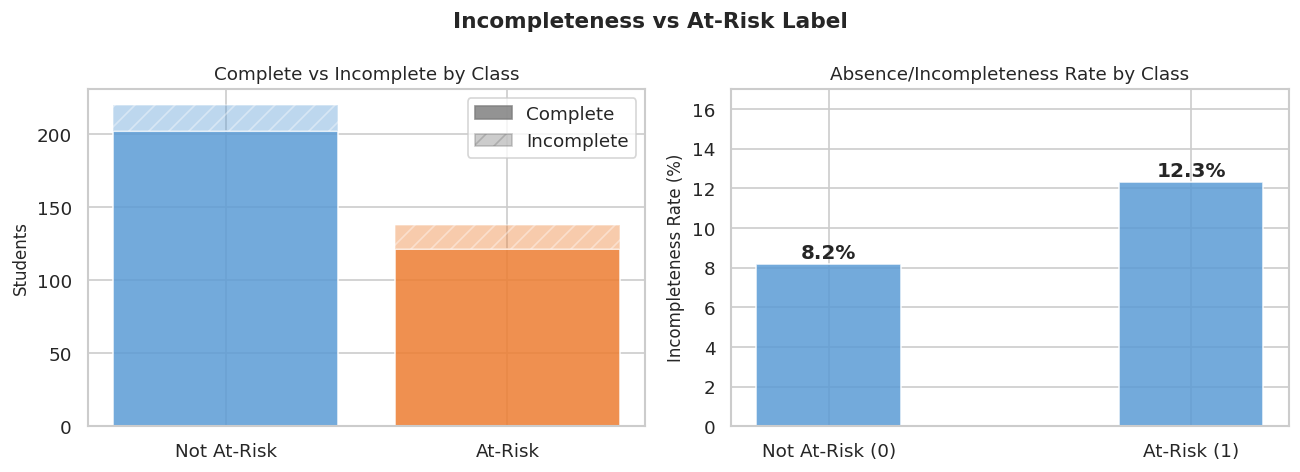

In [13]:
if df['any_incomplete'].sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle('Incompleteness vs At-Risk Label', fontweight='bold', fontsize=13)

    # Stacked bar: incomplete vs complete per class
    ax = axes[0]
    for lbl, color, name in [(0,TYPICAL_COLOR,'Not At-Risk'),(1,AT_RIST_COLOR,'At-Risk')]:
        sub = df[df['Label']==lbl]
        n_inc  = sub['any_incomplete'].sum()
        n_comp = len(sub) - n_inc
        ax.bar(name, n_comp, color=color, alpha=0.85)
        ax.bar(name, n_inc,  bottom=n_comp, color=color, alpha=0.4, hatch='//')
    ax.set_ylabel('Students')
    ax.set_title('Complete vs Incomplete by Class')
    handles = [
        plt.Rectangle((0,0),1,1, color='grey', alpha=0.85, label='Complete'),
        plt.Rectangle((0,0),1,1, color='grey', alpha=0.4, hatch='//', label='Incomplete')
    ]
    ax.legend(handles=handles)

    # Incompleteness rate per class
    ax2 = axes[1]
    rates = [
        df[df['Label']==0]['any_incomplete'].mean()*100,
        df[df['Label']==1]['any_incomplete'].mean()*100
    ]
    bars = ax2.bar(['Not At-Risk (0)', 'At-Risk (1)'], rates,
                   color=[TYPICAL_COLOR,TYPICAL_COLOR], alpha=0.85, width=0.4)
    ax2.set_ylabel('Incompleteness Rate (%)')
    ax2.set_title('Absence/Incompleteness Rate by Class')
    ax2.set_ylim(0, max(rates)*1.3 + 1)
    for bar, rate in zip(bars, rates):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.1f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('No missing values in dataset — incompleteness chart skipped.')

### 2.3 Impute NaNs with per-class median (group-aware)

In [14]:
df[feature_cols] = df.groupby('Label')[feature_cols].transform(
    lambda x: x.fillna(x.median())
)
# Fallback: global median if an entire class column is NaN
df = df.fillna(df.median(numeric_only=True))

### 2.4 Per-Class IQR Clipping
Clipping is done within each class separately. At-Risk students may have genuinely different score ranges — clipping globally would corrupt that signal.

In [15]:
clip_bounds = {}
for col in feature_cols:
    clip_bounds[col] = {}
    for label in df['Label'].unique():
        mask = df['Label'] == label
        Q1 = df.loc[mask, col].quantile(0.25)
        Q3 = df.loc[mask, col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        clip_bounds[col][label] = (lower, upper)
        df.loc[mask, col] = df.loc[mask, col].clip(lower, upper)

df = df.reset_index(drop=True)      # Sanity Check

print('Per-class clipping bounds applied:')
for col, bounds in clip_bounds.items():
    for label, (lo, hi) in bounds.items():
        name = 'Not At-Risk' if label == 0 else 'At-Risk'
        print(f'  {col} [{name}]: [{lo:.2f}, {hi:.2f}]')

Per-class clipping bounds applied:
  NC [At-Risk]: [162.37, 2050.36]
  NC [Not At-Risk]: [271.50, 1503.74]
  DM [At-Risk]: [68.71, 4902.44]
  DM [Not At-Risk]: [271.80, 3541.94]
  NS [At-Risk]: [-3.50, 24.50]
  NS [Not At-Risk]: [2.50, 30.50]
  ADD [At-Risk]: [-10.00, 68.00]
  ADD [Not At-Risk]: [16.50, 68.50]
  SUB [At-Risk]: [-11.50, 64.50]
  SUB [Not At-Risk]: [8.50, 68.50]
  CA [At-Risk]: [-5.88, 37.12]
  CA [Not At-Risk]: [1.88, 46.88]


In [16]:
print('=== Post-clean Summary ===')
print(df.head())
print(df.info())
print('\nRemaining NaNs:', df.isna().sum().sum())

=== Post-clean Summary ===
            NC           DM    NS   ADD   SUB    CA  Label  NC_incomplete  \
0  1248.000000  2903.384615   5.0  23.0  17.0   8.0      1              0   
1   921.142857  2212.000000  21.0  48.0  22.0  29.0      0              0   
2   902.720000  1943.846154  14.0  28.0  26.0  18.0      1              0   
3  1334.297872  3707.268293   9.0  17.0  10.0  14.5      1              0   
4  1274.509804  2384.918919  16.0  34.0  37.0  16.0      0              0   

   DM_incomplete  NS_incomplete  ADD_incomplete  SUB_incomplete  \
0              0              0               0               0   
1              0              0               0               0   
2              0              0               0               0   
3              0              0               0               0   
4              0              0               0               0   

   CA_incomplete  any_incomplete  
0              0               0  
1              0               0  
2 

## 3. Exploratory Data Analysis — After Cleaning

### 3.1 Cleaned Dataset View

In [17]:
df_clean = df.copy()

print("=== Dataset Info ===")
print(df_clean.info())

print("\n=== Dataset Head ===")
print(df_clean.head())

print("\n=== Summary Statistics (raw) ===")
print(df_clean.describe().T.round(2))

print("\n=== Missing / Sentinel Values ===")
sentinel_mask = (df_clean == -99)
print("Cells equal to -99:", sentinel_mask.sum().sum())
print(sentinel_mask.sum()[sentinel_mask.sum() > 0])

print("\n=== Label Distribution ===")
print(df_clean['Label'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NC              358 non-null    float64
 1   DM              358 non-null    float64
 2   NS              358 non-null    float64
 3   ADD             358 non-null    float64
 4   SUB             358 non-null    float64
 5   CA              358 non-null    float64
 6   Label           358 non-null    int64  
 7   NC_incomplete   358 non-null    int64  
 8   DM_incomplete   358 non-null    int64  
 9   NS_incomplete   358 non-null    int64  
 10  ADD_incomplete  358 non-null    int64  
 11  SUB_incomplete  358 non-null    int64  
 12  CA_incomplete   358 non-null    int64  
 13  any_incomplete  358 non-null    int64  
dtypes: float64(6), int64(8)
memory usage: 39.3 KB
None

=== Dataset Head ===
            NC           DM    NS   ADD   SUB    CA  Label  NC_incomplete  \

### 3.2 Feature Distribution

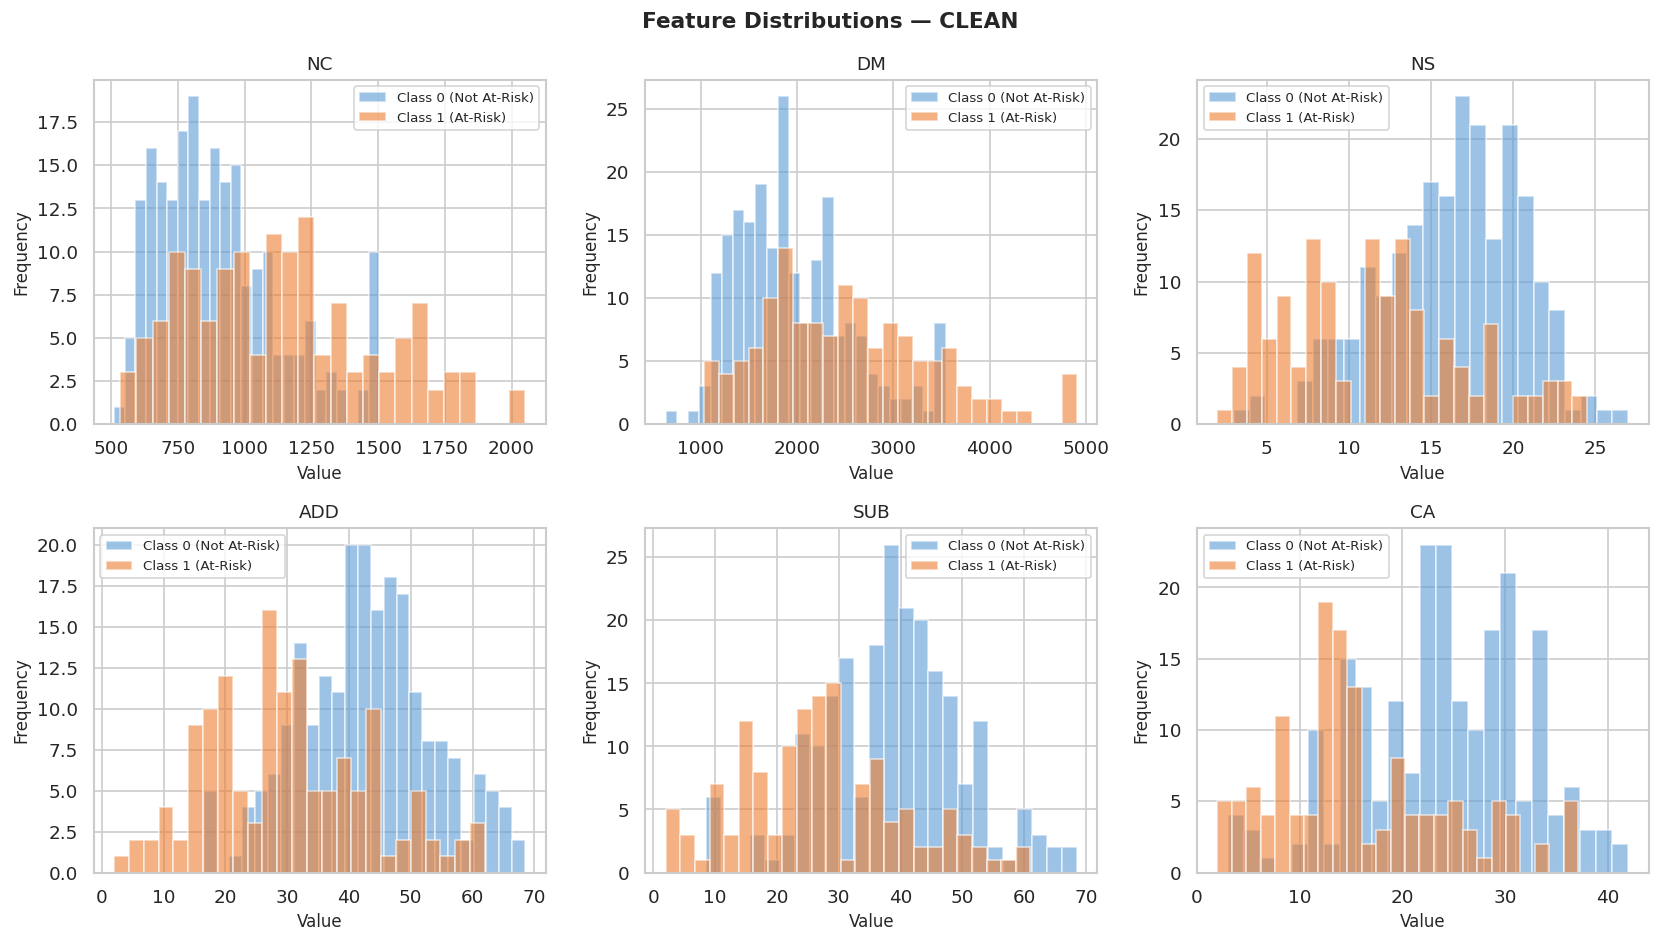

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions — CLEAN', fontweight='bold', fontsize=13)
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    ax = axes[i]
    for label, color in zip([0, 1], [TYPICAL_COLOR, AT_RIST_COLOR]):
        data = df_clean[df_clean['Label'] == label][col]
        ax.hist(data, bins=25, alpha=0.6, color=color,
                label=f'Class {label} ({["Not At-Risk","At-Risk"][label]})', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.3 Feature x Class Outliers

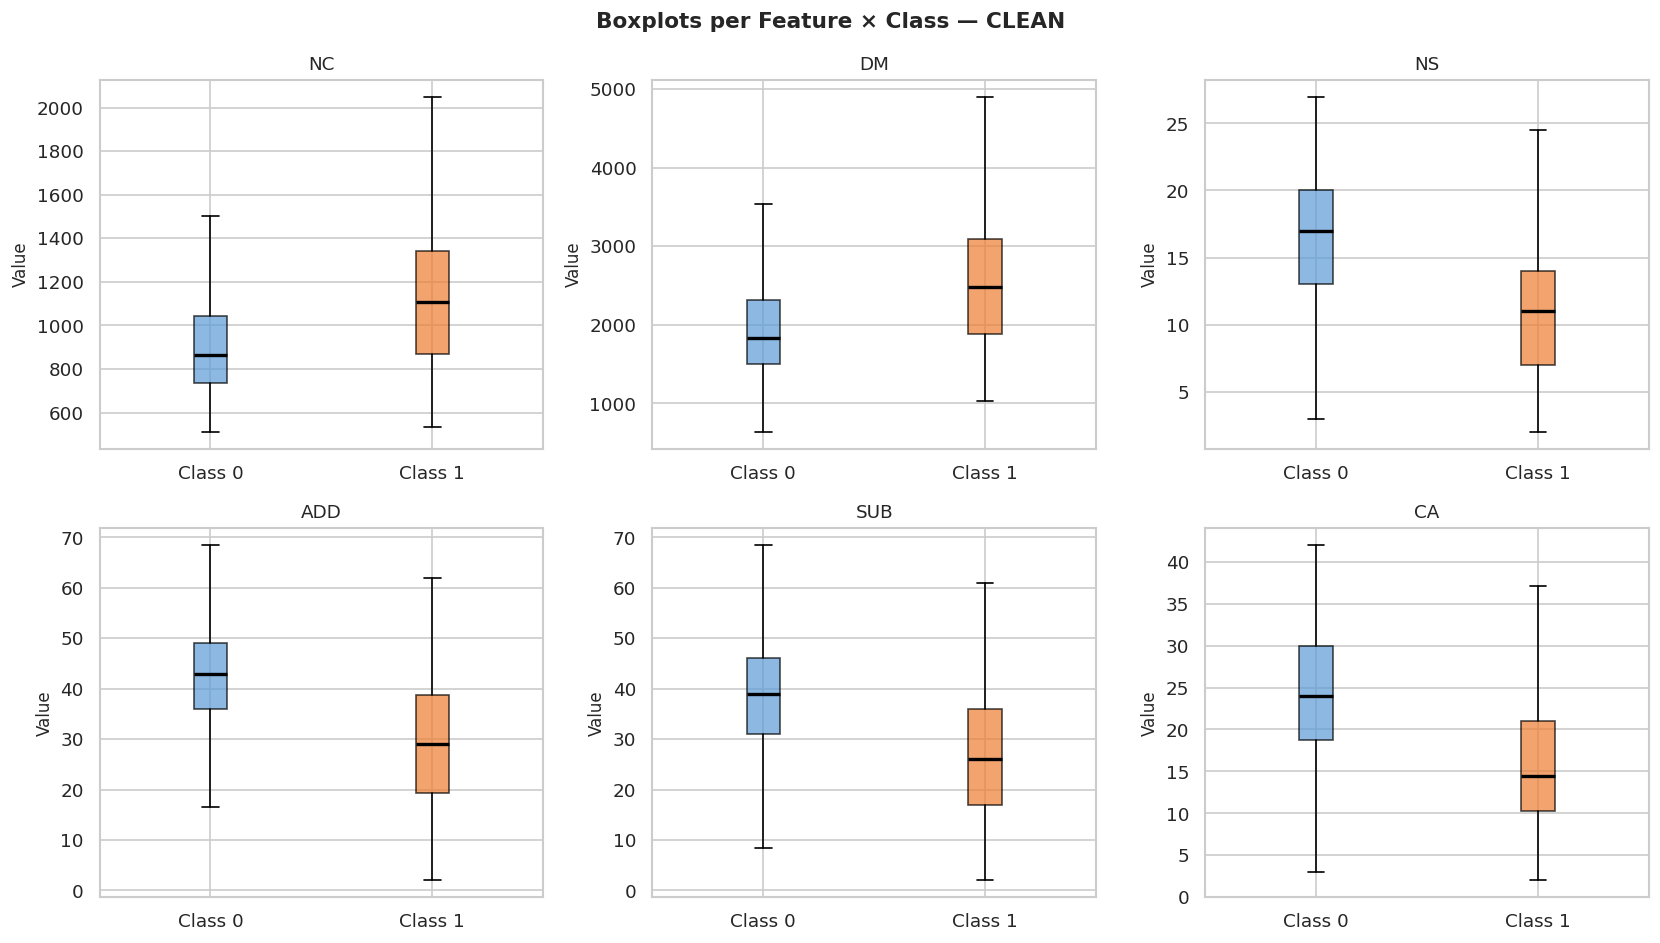

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Boxplots per Feature × Class — CLEAN', fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    data_to_plot = [df_clean[df_clean['Label'] == lbl][col] for lbl in [0, 1]]
    bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], [TYPICAL_COLOR, AT_RIST_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Class 0', 'Class 1'])
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

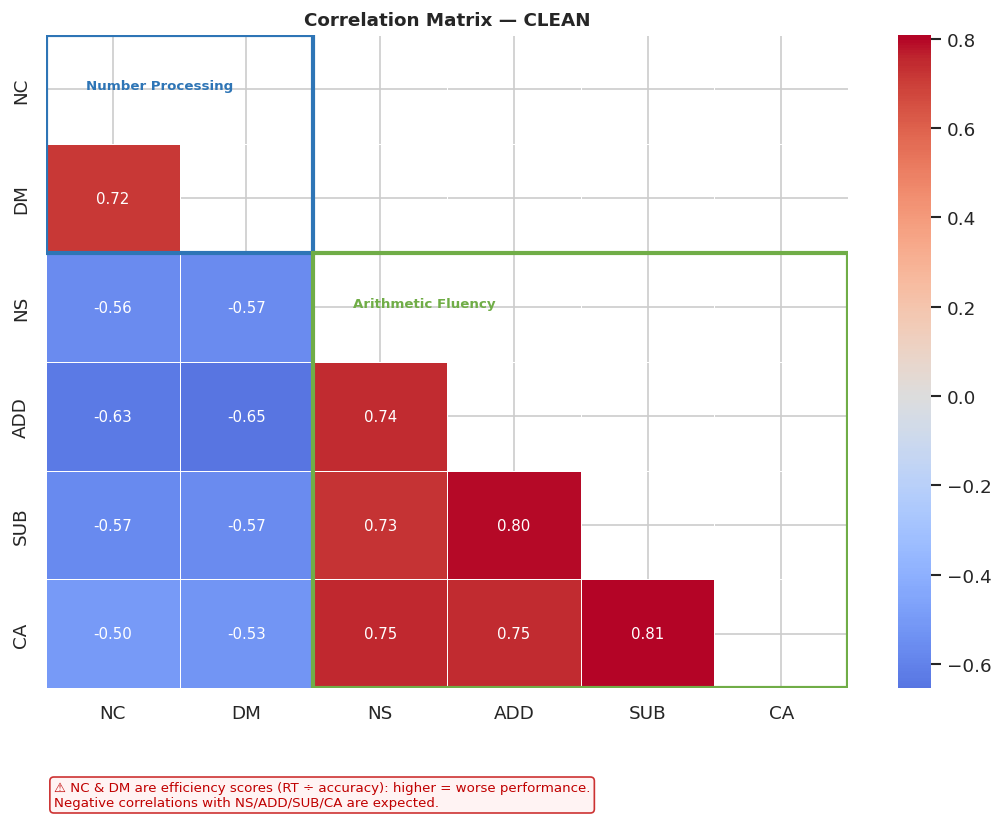

In [20]:
# Two-factor grouping
number_processing = ['NC', 'DM']
arithmetic_fluency = ['NS', 'ADD', 'SUB', 'CA']

# Correlation (exclude Label unless you really need it)
corr_clean = df_clean[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_clean, dtype=bool))

sns.heatmap(corr_clean, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})

ax.set_title('Correlation Matrix — CLEAN', fontweight='bold')

# --- Dynamic mapping (fixes your main issue) ---
col_index = {col: i for i, col in enumerate(corr_clean.columns)}

# Number Processing
np_idx = [col_index[c] for c in number_processing if c in col_index]
if np_idx:
    np_min, np_max = min(np_idx), max(np_idx)
    ax.add_patch(plt.Rectangle(
        (np_min, np_min),
        np_max - np_min + 1,
        np_max - np_min + 1,
        fill=False,
        edgecolor='#2E75B6',
        lw=2.5
    ))
    ax.text(np_min + 0.3, np_min + 0.5, 'Number Processing',
            fontsize=8, color='#2E75B6', fontweight='bold')

# Arithmetic Fluency
af_idx = [col_index[c] for c in arithmetic_fluency if c in col_index]
if af_idx:
    af_min, af_max = min(af_idx), max(af_idx)
    ax.add_patch(plt.Rectangle(
        (af_min, af_min),
        af_max - af_min + 1,
        af_max - af_min + 1,
        fill=False,
        edgecolor='#70AD47',
        lw=2.5
    ))
    ax.text(af_min + 0.3, af_min + 0.5, 'Arithmetic Fluency',
            fontsize=8, color='#70AD47', fontweight='bold')

# --- Stable annotation (fix clipping issue) ---
ax.text(
    0.01, -0.18,
    '⚠ NC & DM are efficiency scores (RT ÷ accuracy): higher = worse performance.\n'
    'Negative correlations with NS/ADD/SUB/CA are expected.',
    transform=ax.transAxes,
    fontsize=8,
    color='#C00000',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='#C00000', alpha=0.8)
)

plt.tight_layout()
plt.show()

### 3.4 Pairplot 

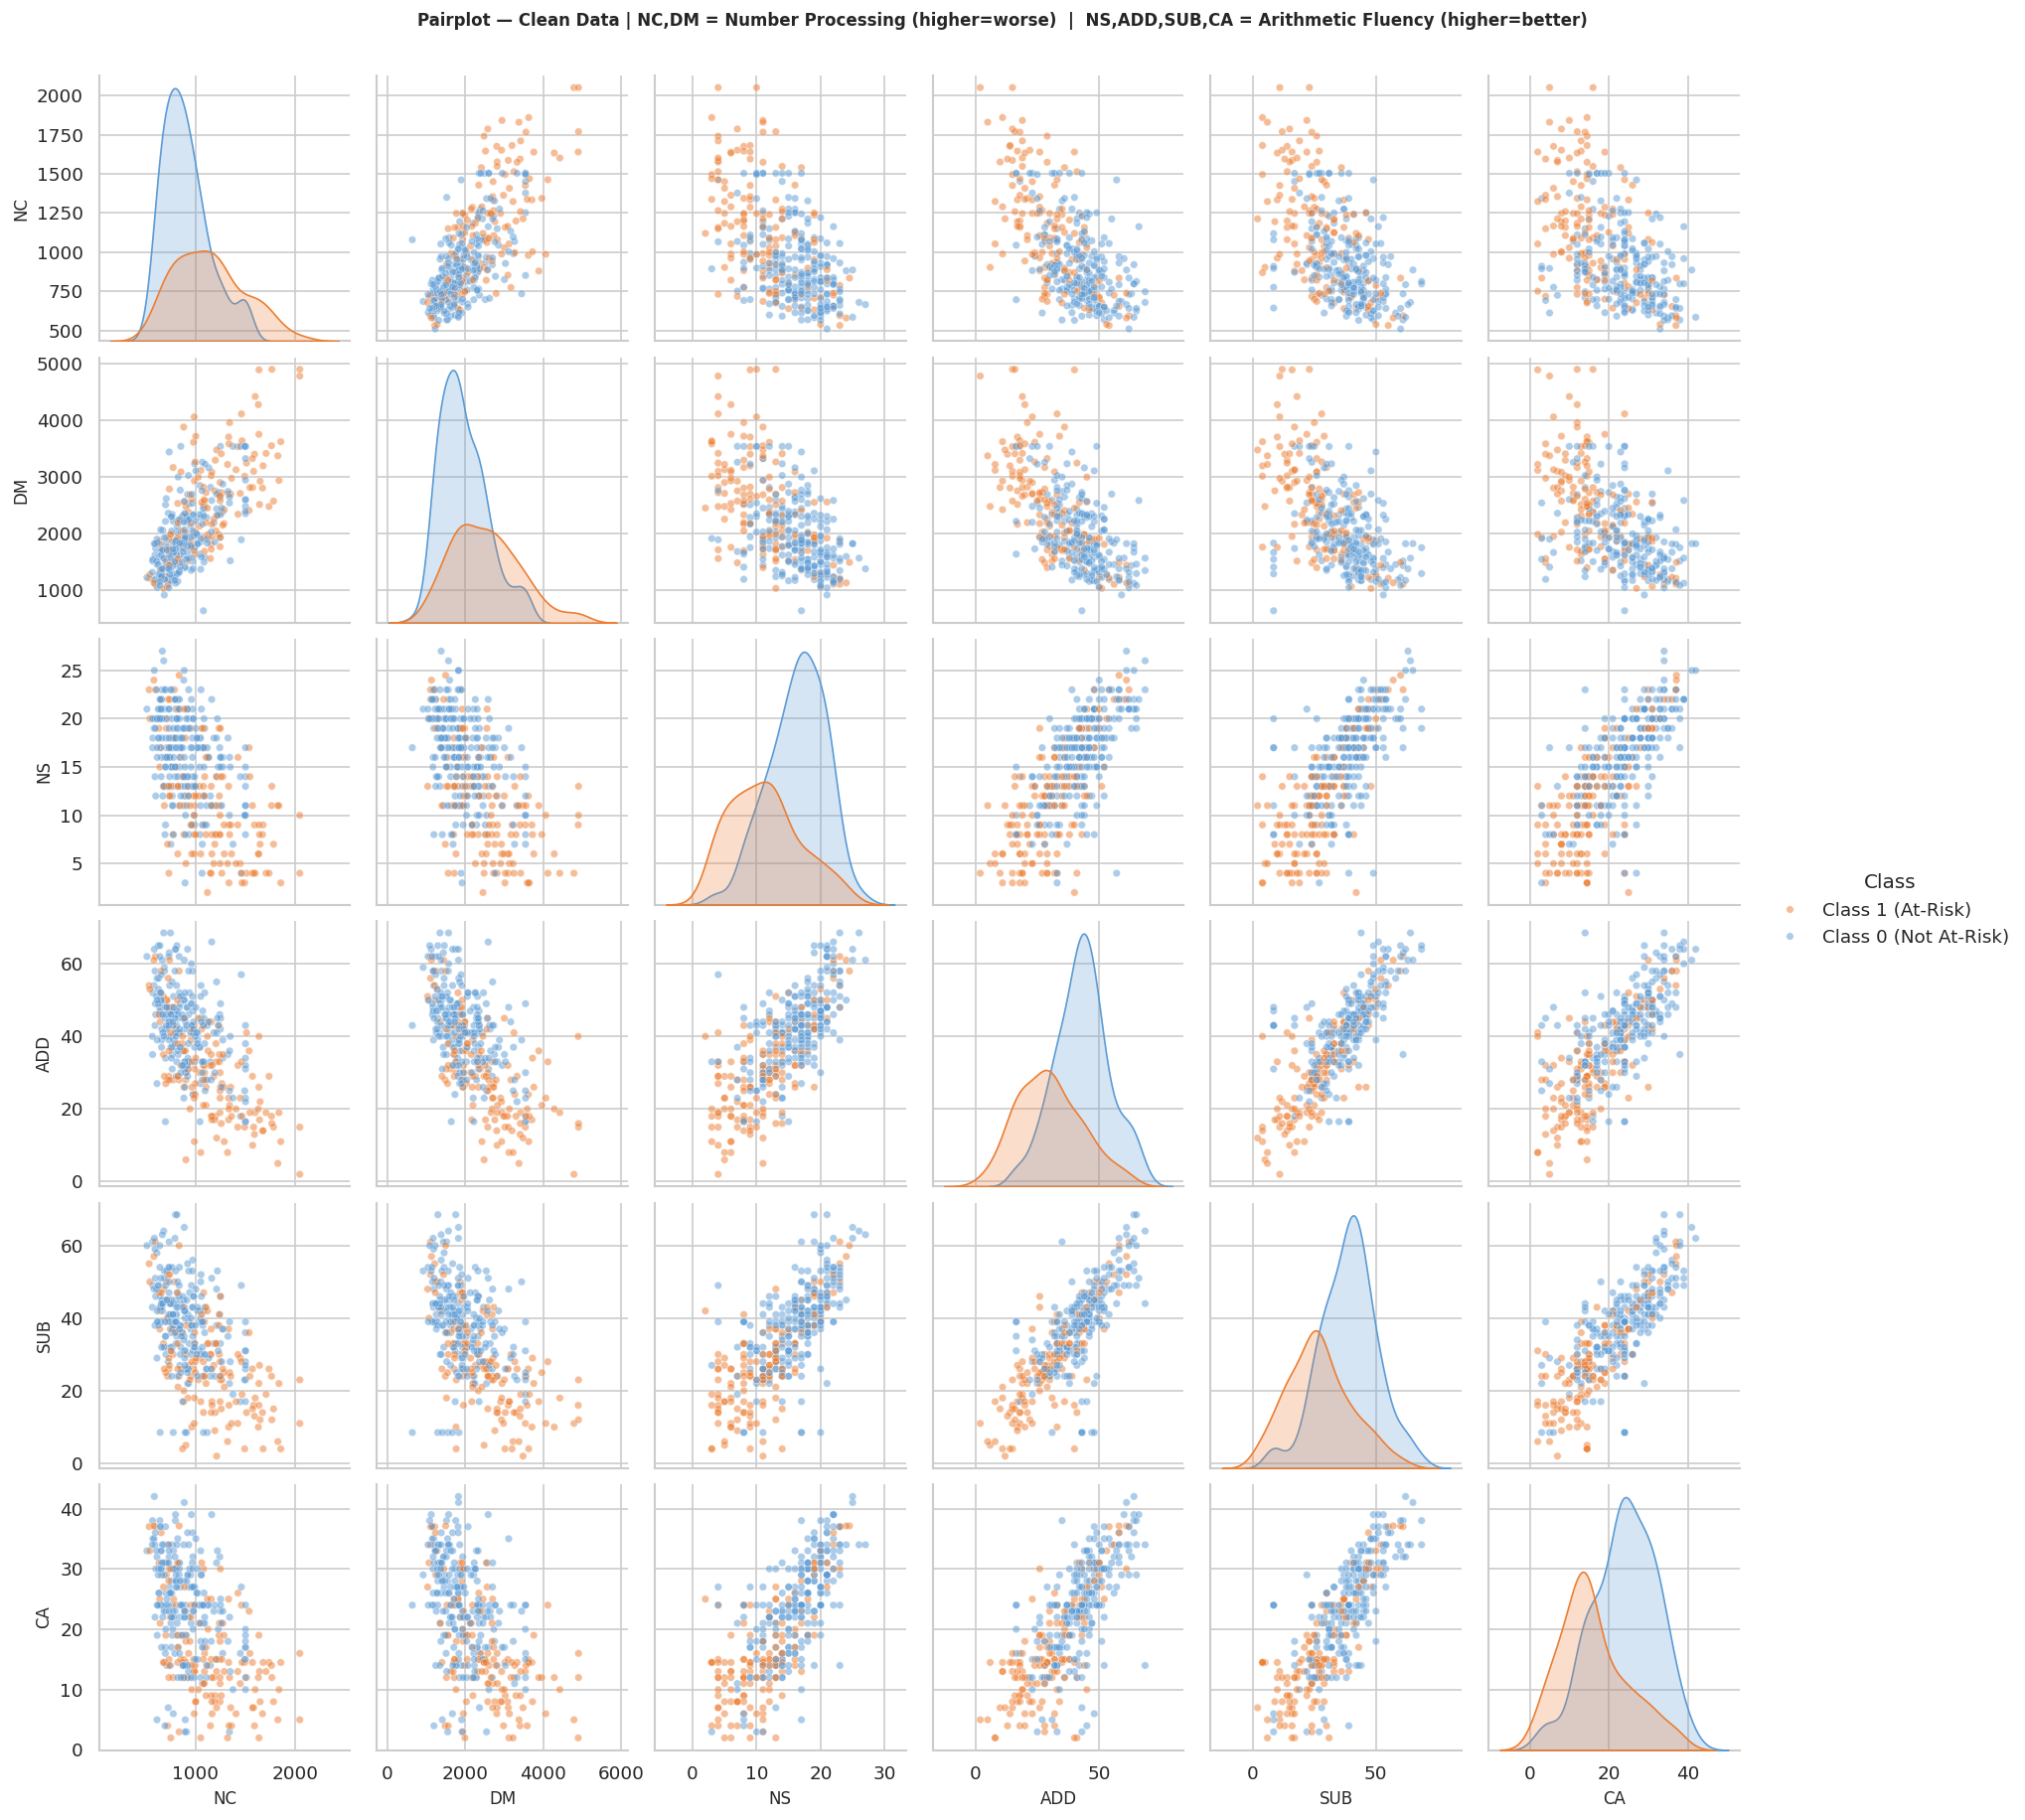

In [21]:
pair_df_c = df_clean.copy()
pair_df_c['Class'] = pair_df_c['Label'].map({0: 'Class 0 (Not At-Risk)', 1: 'Class 1 (At-Risk)'})

# Highlight the two-factor structure with column ordering
# Number Processing: NC, DM | Arithmetic Fluency: NS, ADD, SUB, CA
ordered_cols = ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA']
g = sns.pairplot(pair_df_c, vars=ordered_cols, hue='Class',
                 palette={'Class 0 (Not At-Risk)': TYPICAL_COLOR, 'Class 1 (At-Risk)': AT_RIST_COLOR},
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
g.figure.suptitle(
    'Pairplot — Clean Data | NC,DM = Number Processing (higher=worse)  |  NS,ADD,SUB,CA = Arithmetic Fluency (higher=better)',
    y=1.02, fontweight='bold', fontsize=10)
plt.show()

## 4. Before vs After Comparison

### 4.1 Numeric Comparison

In [22]:
# Numeric comparison table: mean, std, min, max for each feature
rows = []
for col in feature_cols:
    for label, dataset in [('RAW', df_raw), ('CLEAN', df_clean)]:
        s = dataset[col]
        rows.append({
            'Feature': col, 'Dataset': label,
            'Mean': s.mean(), 'Std': s.std(),
            'Min': s.min(), 'Max': s.max(),
            'NaN': s.isna().sum()
        })

comparison = pd.DataFrame(rows).set_index(['Feature', 'Dataset']).round(2)
print(comparison.to_string())

                    Mean     Std     Min      Max  NaN
Feature Dataset                                       
NC      RAW       993.86  329.90  -99.00  2399.14    0
        CLEAN     994.96  305.99  510.82  2050.36    0
DM      RAW      2158.84  813.41  -99.00  5217.22    0
        CLEAN    2171.81  770.70  637.50  4902.44    0
NS      RAW        11.88   17.64  -99.00    27.00    0
        CLEAN      14.38    5.44    2.00    27.00    0
ADD     RAW        34.87   24.30  -99.00    70.00    0
        CLEAN      37.96   13.30    2.00    68.50    0
SUB     RAW        30.18   26.66  -99.00    71.00    0
        CLEAN      34.32   13.34    2.00    68.50    0
CA      RAW        12.00   33.01  -99.00    42.00    0
        CLEAN      20.94    9.12    2.00    42.00    0


## 5. Save Cleaned Dataset

In [24]:
df_clean.to_csv('dataset/cleaned_dataset.csv', index=False)